##assignment 1



## # Assignment 1: Student Performance Prediction

Dear Students,
Aap sab ko **Student Performance Dataset** assign ki ja rahi hai.
### Task:
Is dataset par **Linear Regression** apply karni hai aur **Exam Score** ko predict karna hai.
**Target Column (Prediction):**
* `Exam_Score`
Baaki numeric columns ko features ke taur par use karein.

### Submission Requirements:

* Complete Jupyter Notebook (.ipynb)
* Dataset
* Proper comments in code
* Model Evaluation (MAE, MSE, RMSE, R² Score)
* Prediction Results

**Submission Deadline:**
**29 July 2026 (29/07/2026)**

Apna complete project GitHub par upload karein aur GitHub repository ka link submit karein.

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [53]:
df = pd.read_csv("student_performance.csv")

In [54]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Hours Studied                     10000 non-null  int64
 1   Previous Scores                   10000 non-null  int64
 2   Extracurricular Activities        10000 non-null  str  
 3   Sleep Hours                       10000 non-null  int64
 4   Sample Question Papers Practiced  10000 non-null  int64
 5   Performance Index                 10000 non-null  int64
dtypes: int64(5), str(1)
memory usage: 468.9 KB


In [56]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [57]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [58]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 127


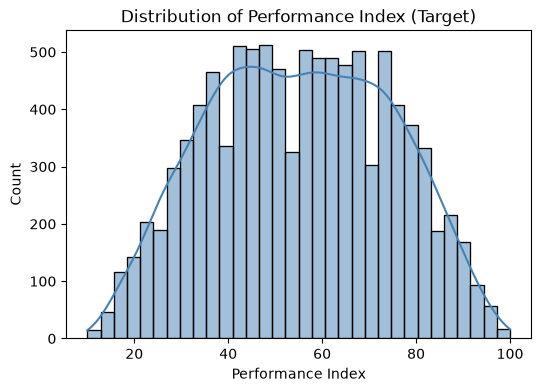

In [59]:
# Distribution of the target variable
plt.figure(figsize=(6, 4))
sns.histplot(df["Performance Index"], kde=True, color="steelblue")
plt.title("Distribution of Performance Index (Target)")
plt.xlabel("Performance Index")
plt.show()

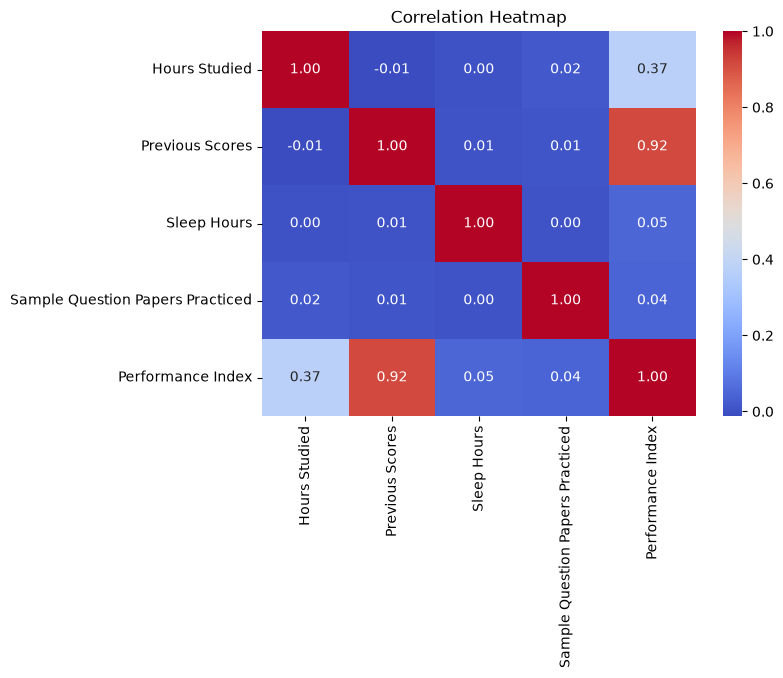

In [60]:
# Correlation heatmap (numeric columns only)
plt.figure(figsize=(7, 5))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

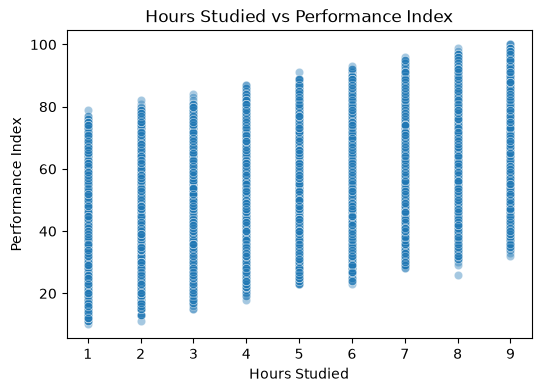

In [61]:
# Relationship between Hours Studied and Performance Index
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df["Hours Studied"], y=df["Performance Index"], alpha=0.4)
plt.title("Hours Studied vs Performance Index")
plt.xlabel("Hours Studied")
plt.ylabel("Performance Index")
plt.show()

In [62]:
# 'Extracurricular Activities' is categorical (Yes/No) - encode it as 0/1
df["Extracurricular Activities"] = df["Extracurricular Activities"].map({"Yes": 1, "No": 0})

df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91
1,4,82,0,4,2,65
2,8,51,1,7,2,45
3,5,52,1,5,2,36
4,7,75,0,8,5,66


In [63]:
# Separate features (X) and target (y)
X = df.drop("Performance Index", axis=1)
y = df["Performance Index"]

print("Features:", list(X.columns))
print("Target: Performance Index")

Features: ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']
Target: Performance Index


In [64]:
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8000
Testing samples: 2000


In [65]:
print(df["Extracurricular Activities"].unique())

[1 0]


In [66]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# View learned coefficients
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
coeff_df

,Coefficient
Hours Studied,2.852484
Previous Scores,1.016988
Extracurricular Activities,0.608617
Sleep Hours,0.476941
Sample Question Papers Practiced,0.191831


In [67]:
# Intercept of the model
print("Intercept:", model.intercept_)

Intercept: -33.921946215556126


In [68]:
# Predict on the test set
y_pred = model.predict(X_test)

# Compare actual vs predicted values
results_df = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred})
results_df.head(10)

,Actual,Predicted
0,51,54.711854
1,20,22.615513
2,46,47.903145
3,28,31.289767
4,41,43.004570
5,59,59.071252
6,48,45.903475
7,87,86.459118
8,37,37.700140
9,73,72.055925


In [70]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 3))
print("Mean Squared Error (MSE):", round(mse, 3))
print("Root Mean Squared Error (RMSE):", round(rmse, 3))
print("R2 Score:", round(r2, 3))

NameError: name 'mean_absolute_error' is not defined

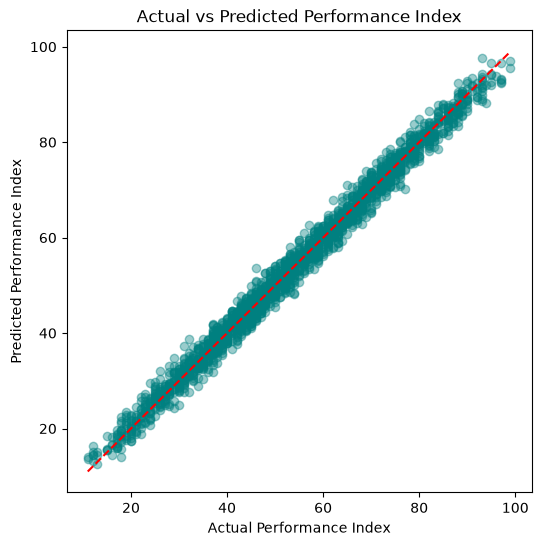

In [71]:
# Visualize Actual vs Predicted values
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Actual vs Predicted Performance Index")
plt.show()

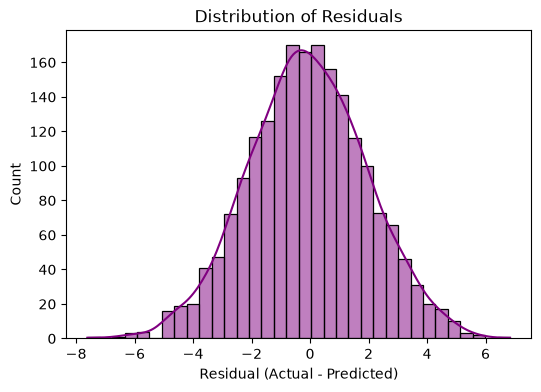

In [72]:
# Residual plot (errors should be randomly scattered around 0)
residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True, color="purple")
plt.title("Distribution of Residuals")
plt.xlabel("Residual (Actual - Predicted)")
plt.show()